# IN5437 — Assignment 1
## Question 9: Image Sharpening

**Name:** Benjamine  
**Index:** 258762A

Apply image sharpening to enhance edges and fine detail.

Two common approaches:
- **Unsharp masking:** `Sharpened = Original + amount × (Original − Blurred)`
- **Laplacian sharpening:** `Sharpened = Original − Laplacian(Original)`

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Load the image

Shape: (217, 181)


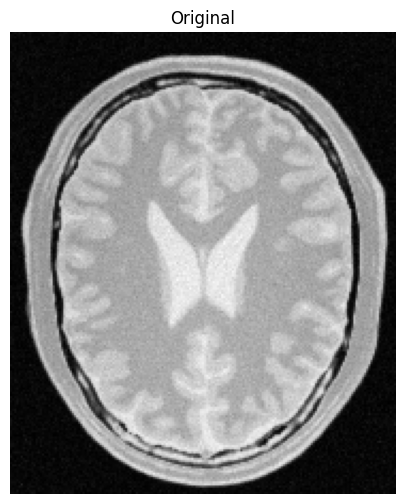

In [21]:
q9_im = cv.imread('../images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)
assert q9_im is not None, "File could not be read. Check the path."

print('Shape:', q9_im.shape)

plt.figure(figsize=(6, 6))
plt.imshow(q9_im, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.axis('off')
plt.show()

### Method 1: Unsharp masking

Step 1: blur the image (low-frequency content)  
Step 2: subtract blurred from original (high-frequency mask)  
Step 3: add mask back to original, scaled by `amount`

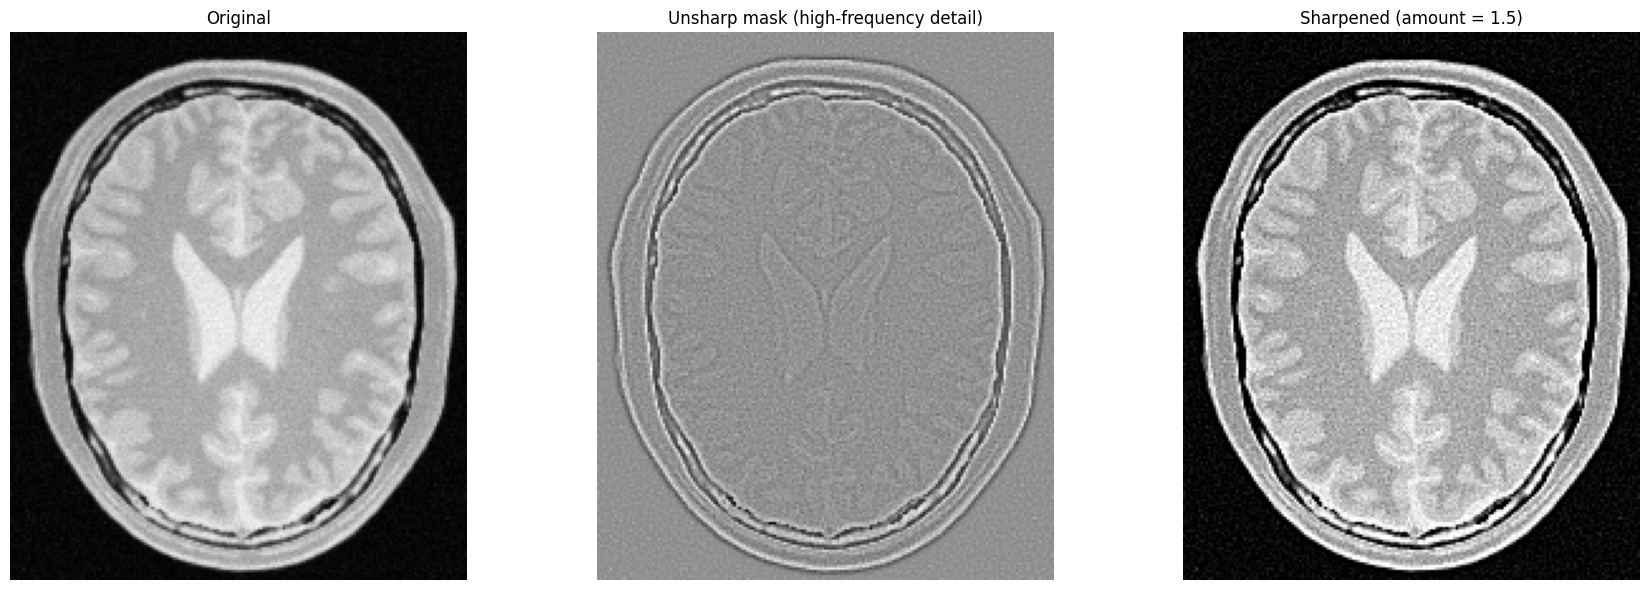

In [22]:
# Parameters
amount = 1.5      # strength of sharpening
blur_sigma = 1.0

# Step 1: blur
blurred = cv.GaussianBlur(q9_im, (5, 5), blur_sigma)

# Step 2: mask = original − blurred (work in float to keep negatives)
mask = q9_im.astype(np.float32) - blurred.astype(np.float32)

# Step 3: add scaled mask back to original
sharpened = q9_im.astype(np.float32) + amount * mask

# Clip to valid 8-bit range and convert back
g_9a = np.clip(sharpened, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(q9_im,   cmap='gray', vmin=0, vmax=255);           ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(mask,    cmap='gray');                             ax[1].set_title('Unsharp mask (high-frequency detail)'); ax[1].axis('off')
ax[2].imshow(g_9a,    cmap='gray', vmin=0, vmax=255);           ax[2].set_title(f'Sharpened (amount = {amount})'); ax[2].axis('off')
plt.tight_layout()
plt.show()

### Method 2: Laplacian sharpening

Apply the Laplacian operator to highlight edges, then subtract from the original.

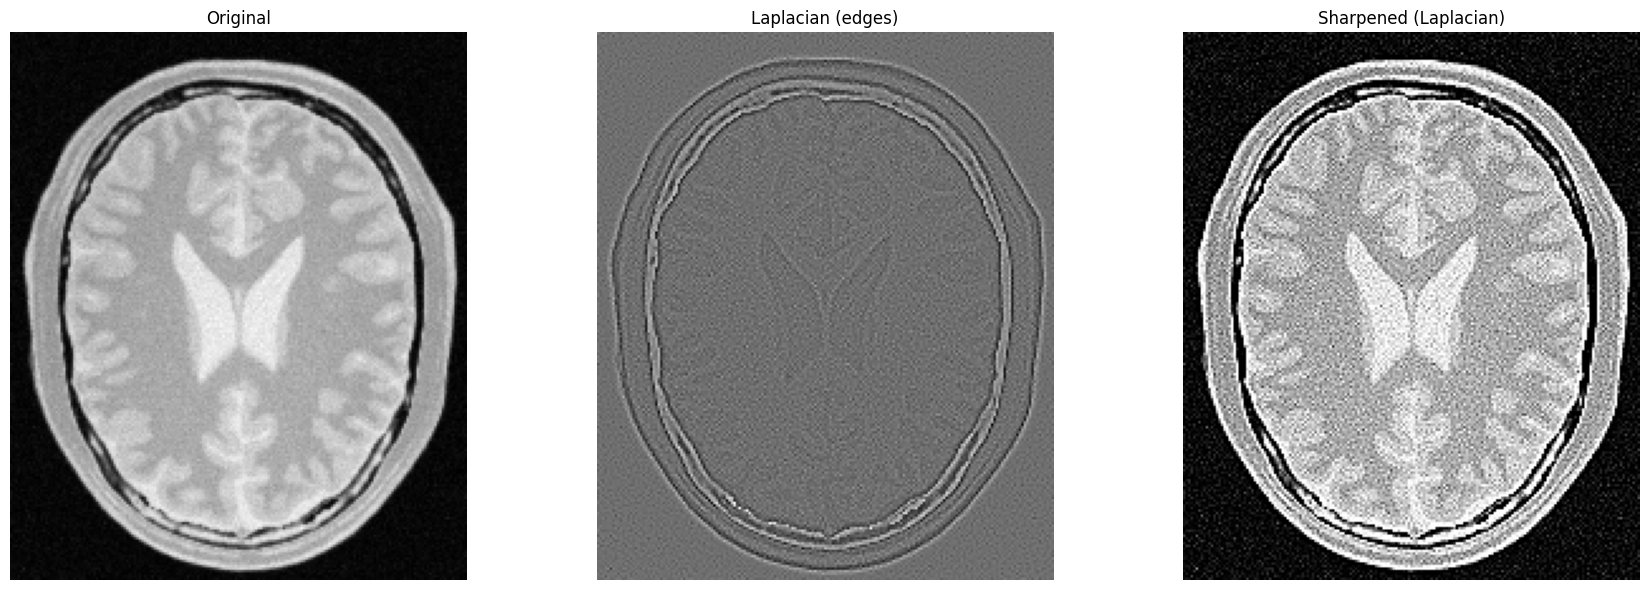

In [23]:
# Compute the Laplacian (use CV_64F to keep negative values)
laplacian = cv.Laplacian(q9_im, cv.CV_64F)

# Subtract from original to sharpen
sharpened_lap = q9_im.astype(np.float64) - laplacian

# Clip and convert back to uint8
g_9b = np.clip(sharpened_lap, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(q9_im,     cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(laplacian, cmap='gray');                   ax[1].set_title('Laplacian (edges)'); ax[1].axis('off')
ax[2].imshow(g_9b,      cmap='gray', vmin=0, vmax=255); ax[2].set_title('Sharpened (Laplacian)'); ax[2].axis('off')
plt.tight_layout()
plt.show()

### Side-by-side comparison: Original vs Unsharp masking vs Laplacian

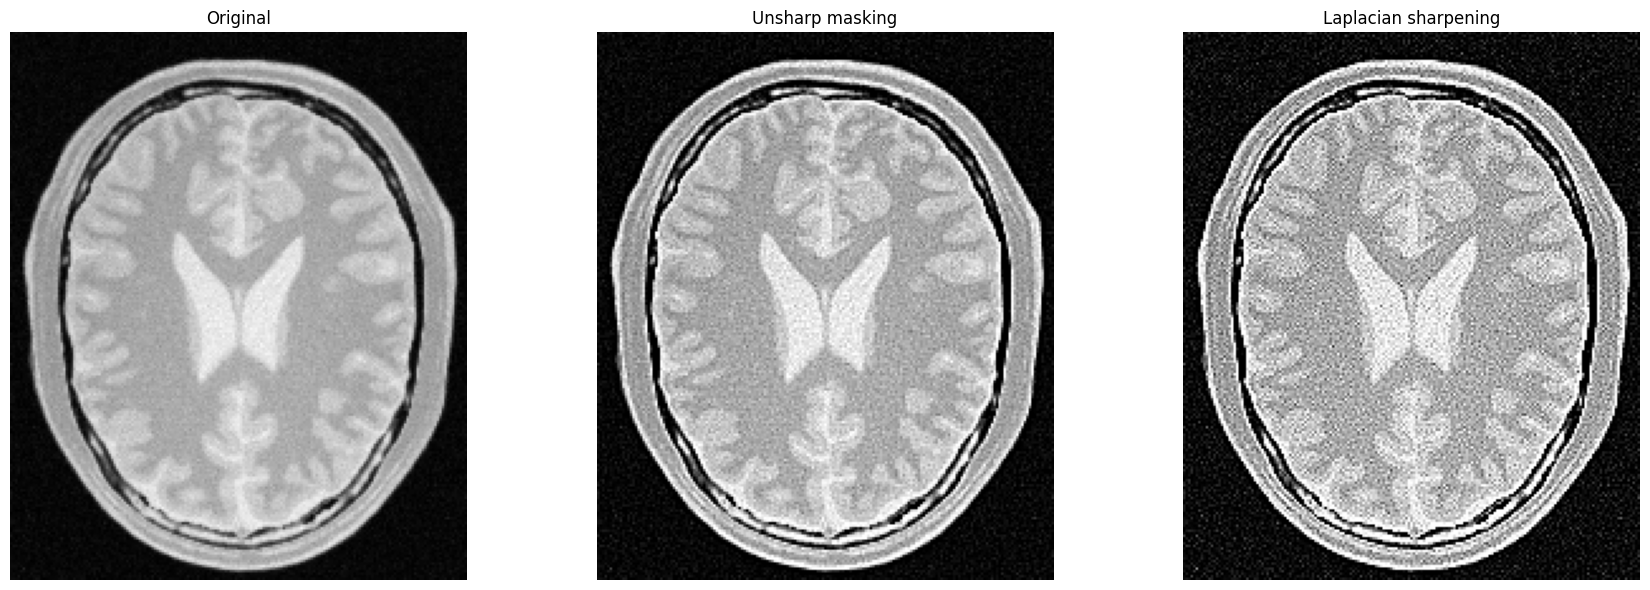

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(q9_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original');                   ax[0].axis('off')
ax[1].imshow(g_9a,  cmap='gray', vmin=0, vmax=255); ax[1].set_title('Unsharp masking');            ax[1].axis('off')
ax[2].imshow(g_9b,  cmap='gray', vmin=0, vmax=255); ax[2].set_title('Laplacian sharpening');       ax[2].axis('off')
plt.tight_layout()
plt.show()

### Try different sharpening strengths (unsharp masking)

Demonstrate how the `amount` parameter controls sharpening intensity.

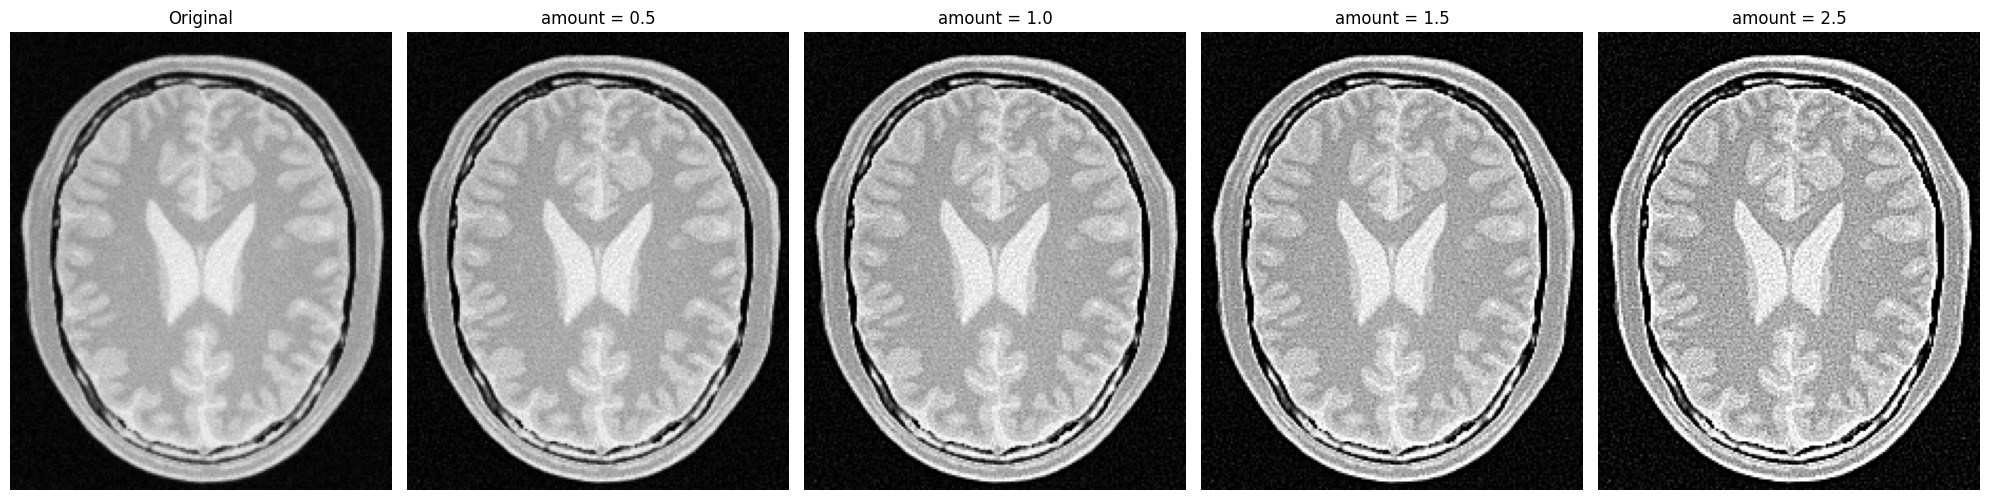

In [25]:
amounts = [0.5, 1.0, 1.5, 2.5]
blurred = cv.GaussianBlur(q9_im, (5, 5), 1.0)
mask = q9_im.astype(np.float32) - blurred.astype(np.float32)

fig, ax = plt.subplots(1, len(amounts) + 1, figsize=(4 * (len(amounts) + 1), 5))
ax[0].imshow(q9_im, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Original'); ax[0].axis('off')

for i, amt in enumerate(amounts):
    sharp = np.clip(q9_im.astype(np.float32) + amt * mask, 0, 255).astype(np.uint8)
    ax[i + 1].imshow(sharp, cmap='gray', vmin=0, vmax=255)
    ax[i + 1].set_title(f'amount = {amt}')
    ax[i + 1].axis('off')

plt.tight_layout()
plt.show()

### Observation

**Unsharp masking.** The mask image in Method 1 clearly shows high-frequency detail — edges of brain structures, boundaries between tissue types, and fine texture — as bright and dark values on a uniform gray background. Regions of smooth intensity (uniform tissue interior) appear as mid-gray since the original and the blurred version are similar there. Adding a scaled version of this mask back to the original enhances edge contrast and makes the fine structures inside the brain more visible. For this image, `amount = 1.5` produces a noticeable but natural-looking result.

**Laplacian sharpening.** The Laplacian response is strongest where intensity changes rapidly — at the sharp boundaries inside the MRI slice. Subtracting the Laplacian from the original amplifies these transitions. The overall effect is similar to unsharp masking, but the edges look slightly harsher because the Laplacian (second derivative) responds more strongly than the first-derivative-based difference used in unsharp masking.

**Effect of the `amount` parameter.** The parameter sweep in Cell 11 shows a clear progression:
- `amount = 0.5` — subtle improvement, barely noticeable
- `amount = 1.0` — cleanly enhanced, no artifacts
- `amount = 1.5` — strong sharpening, fine detail very visible (good middle ground)
- `amount = 2.5` — over-sharpening begins; halos appear around edges and noise is amplified

**Trade-off.** Sharpening is essentially a high-pass filter in the frequency domain — it boosts high-frequency content (edges, noise, detail) and relatively suppresses low-frequency content (smooth regions). This means sharpening always amplifies any noise present in the image along with the desired detail. Choosing a moderate `amount` (0.8 – 1.5) gives useful enhancement without visible artifacts. This frequency-domain interpretation connects directly to the discussion in Question 11.